# Task 3

In [9]:
import numpy as np
from math import factorial, exp

#  Task 3: Policy evaluation for "maintain at failure only" 
# We chose the method with the exact solution via V^π = (I - γP^π)^{-1} R^π (formula from slides)

#  Parameters 
gamma = 0.9          #Discount 
lam = 0.5           # Poisson degradation 
xi1, xi2 = 5, 7     # failure for M1, M2
n_x1 = xi1 + 1      # Deg states for M1: 0..5
n_x2 = xi2 + 1      # Deg states for M2: 0..7
n_E = 7              # Engineer phases: 0..6
n_states = n_x1 * n_x2 * n_E  # 6*8*7 = 336

#  State indexing: (x1, x2, E) -> flat index 
def idx(x1, x2, E):
    return x1 * n_x2 * n_E + x2 * n_E + E
    #We need this, because we are using a flat array to represent the state space and Every state gets a unique number from 0 to 335.

#  Truncated Poisson(0.5) degradation probabilities 
# p_i(x, x'): prob of going from state x to x', lumped at failure threshold
# We use the formula from our paper
def poisson_deg(x, xi):
    probs = np.zeros(xi + 1)
    for xp in range(x, xi):
        y = xp - x
        probs[xp] = exp(-lam) * lam**y / factorial(y)
    probs[xi] = 1.0 - probs.sum()  # lump all overflow at failure
    return probs

# precompute: deg1[x] = prob vector from x for M1, deg2[x] for M2
deg1 = np.array([poisson_deg(x, xi1) for x in range(n_x1)])  # (6, 6)
deg2 = np.array([poisson_deg(x, xi2) for x in range(n_x2)])  # (8, 8)

#  Helper function: fill joint degradation transitions into P row ,makes life easier,handles 
def fill_joint(P, s, d1_row, d2_row, target_E):
    """Fill P[s, :] with joint independent degradation probs going to target_E."""
    targets = [idx(x1p, x2p, target_E) for x1p in range(n_x1) for x2p in range(n_x2)]
    P[s, targets] = np.outer(d1_row, d2_row).flatten()

#  Build P^π (transition matrix) and R^π (cost vector) under the policy 
P = np.zeros((n_states, n_states))
R = np.zeros(n_states)

for x1 in range(n_x1):
    for x2 in range(n_x2):
        for E in range(n_E):
            s = idx(x1, x2, E)

            if E == 0:
                #  Decision point (depot) 
                if x1 < xi1 and x2 < xi2: #Both are below failure threshold
                    # do nothing: cost=0, both degrade, stay at depot
                    R[s] = 0
                    fill_joint(P, s, deg1[x1], deg2[x2], 0)

                elif x1 == xi1 and x2 < xi2: #M1 is at failure, M2 is below failure
                    # maintain M1: travel to M1. M1 stays at 5, M2 degrades
                    R[s] = 1  # M1 unavailable
                    for x2p in range(n_x2):
                        P[s, idx(xi1, x2p, 1)] = deg2[x2, x2p]

                elif x1 < xi1 and x2 == xi2: #M1 is below failure, M2 is at failure
                    # maintain M2: travel to M2. M2 stays at 7, M1 degrades
                    R[s] = 1  # M2 unavailable
                    for x1p in range(n_x1):
                        P[s, idx(x1p, xi2, 2)] = deg1[x1, x1p]

                else:  # both failed
                    # tiebreaker: maintain M2 first. No degradation (both at failure)
                    R[s] = 2  # both unavailable
                    P[s, idx(xi1, xi2, 2)] = 1.0

            elif E == 1:
                #  At M1, performing repair 
                if x1 == xi1:  # corrective (only reachable case under this policy)
                    R[s] = 6 + (1 if x2 == xi2 else 0)  # CM(5) + unavail_M1(1) + unavail_M2
                    for x2p in range(n_x2):
                        P[s, idx(xi1, x2p, 3)] = deg2[x2, x2p]  # M2 degrades
                else:
                    R[s] = 0; P[s, s] = 1.0  # unreachable, absorbing

            elif E == 3:
                #  M1 repair: phase 1 done 
                if x1 == xi1:  # CM continues to phase 2
                    R[s] = 1 + (1 if x2 == xi2 else 0)  # M1 still unavail + unavail_M2
                    for x2p in range(n_x2):
                        P[s, idx(xi1, x2p, 4)] = deg2[x2, x2p]
                else:
                    R[s] = 0; P[s, s] = 1.0  # unreachable

            elif E == 4:
                #  M1 CM done, travel back. M1 repaired, degrades from 0 
                if x1 == xi1:
                    R[s] = 1 if x2 == xi2 else 0  # only M2 unavail if failed
                    fill_joint(P, s, deg1[0], deg2[x2], 0)  # M1 fresh, both degrade
                else:
                    R[s] = 0; P[s, s] = 1.0

            elif E == 2:
                #  At M2, performing repair 
                if x2 == xi2:  # corrective (only reachable case)
                    R[s] = 6 + (1 if x1 == xi1 else 0)  # CM(5) + unavail_M2(1) + unavail_M1
                    for x1p in range(n_x1):
                        P[s, idx(x1p, xi2, 5)] = deg1[x1, x1p]  # M1 degrades
                else:
                    R[s] = 0; P[s, s] = 1.0

            elif E == 5:
                #  M2 repair: phase 1 done 
                if x2 == xi2:  # CM continues to phase 2
                    R[s] = 1 + (1 if x1 == xi1 else 0)  # M2 still unavail + unavail_M1
                    for x1p in range(n_x1):
                        P[s, idx(x1p, xi2, 6)] = deg1[x1, x1p] # M1 degrades
                else:
                    R[s] = 0; P[s, s] = 1.0

            elif E == 6:
                #  M2 CM done, travel back. M2 repaired, degrades from 0 
                if x2 == xi2:
                    R[s] = 1 if x1 == xi1 else 0  # only M1 unavail if failed
                    fill_joint(P, s, deg1[x1], deg2[0], 0)  # M2 fresh, both degrade
                else:
                    R[s] = 0; P[s, s] = 1.0

#fCompleted todo, sanity check below.
#Sanity check: each row of P must sum to 1 
row_sums = P.sum(axis=1)
assert np.allclose(row_sums, 1.0), f"Row sums deviate! Max error: {np.max(np.abs(row_sums - 1))}"
print("P rows all sum to 1 ✓")

#  Solve V^π = (I - γP)^{-1} R  (exact solution) 
I_mat = np.identity(n_states)
V = np.dot(np.linalg.inv(I_mat - np.multiply(gamma, P)), R)  # using same formula from hint

#  Output 
s0 = idx(0, 0, 0)
print(f"\nTotal expected discounted cost from healthy state:")
print(f"  V^π(0, 0, 0) = {V[s0]:.6f}")



P rows all sum to 1 ✓

Total expected discounted cost from healthy state:
  V^π(0, 0, 0) = 5.794674


# Task 4

In [ ]:
#  Task 4: Value Iteration for the Optimal Maintenance Policy
# We use VI because it finds the optimal policy without needing to guess one first.
# Synchronous Bellman backup, stop when L-inf norm drops below eps = 1e-8.
import numpy as np
from math import factorial, exp

# Same parameters as Task 3
gamma = 0.9
lam = 0.5
xi1, xi2 = 5, 7
n_x1, n_x2, n_E = xi1 + 1, xi2 + 1, 7  # 6 x 8 x 7 = 336 states
INF = 1e18  # some big number assigned in order to penalise "do-nothing" action
eps = 1e-8  # L-inf convergence threshold

def idx(x1, x2, E):
    return x1 * n_x2 * n_E + x2 * n_E + E #flatten as done in  Task 3

def poisson_deg(x, xi): #same as done in Task 3
    probs = np.zeros(xi + 1)
    for xp in range(x, xi):
        y = xp - x
        probs[xp] = exp(-lam) * lam**y / factorial(y)
    probs[xi] = 1.0 - probs.sum()
    return probs 

# precompute degradation tables for both machines, same as Task 3
deg1 = np.array([poisson_deg(x, xi1) for x in range(n_x1)])  # (6, 6)
deg2 = np.array([poisson_deg(x, xi2) for x in range(n_x2)])  # (8, 8)

def Vmat(V, E):
    # pulls out V(x1, x2, E) for all (x1,x2) as a 2D matrix,it lets us do matrix multiplications instead of nested loops
    M = np.empty((n_x1, n_x2))
    for x1 in range(n_x1):
        for x2 in range(n_x2):
            M[x1, x2] = V[idx(x1, x2, E)]
    return M

#  INIT
V = np.zeros(n_x1 * n_x2 * n_E)  # V_0 = 0 everywhere, doesn't matter for convergence
pi = np.zeros((n_x1, n_x2), dtype=int)  # optimal action at E=0, gets updated each iteration
deltas = []  # track delta_k so we can plot convergence later
n_iter = 0

# VI main loop — synchronous backup, we use old V throughout and swap at the end
while True:
    V_new  = np.zeros_like(V)
    n_iter += 1

    VS = [Vmat(V, E) for E in range(n_E)]  # VS[E][x1, x2] = V(x1, x2, E)

    # precompute "travel home" expected values — reused at both PM-done and CM-done phases
    # home1[x2] = expected V*(x1',x2',0) when M1 just repaired (fresh at 0), M2 at x2, both degrade home
    # home2[x1] = symmetric for M2 just repaired
    home1 = deg1[0] @ VS[0] @ deg2.T  # shape (n_x2,)
    home2 = deg1    @ VS[0] @ deg2[0] # shape (n_x1,)

    #  E = 0: decision point — only place where the action is chosen
    # Q(a)[x1,x2] = immediate cost(a) + gamma * expected V at next E-phase
    Q0 = gamma * (deg1 @ VS[0] @ deg2.T)  # do nothing: both degrade, stay at depot E=0
    Q1 = gamma * (deg1 @ VS[1] @ deg2.T)  # go to M1: both degrade during travel, arrive at E=1
    Q2 = gamma * (deg1 @ VS[2] @ deg2.T)  # go to M2: both degrade during travel, arrive at E=2

    # unavailability cost during travel — 1 per failed machine while engineer is en route
    unavail = np.zeros((n_x1, n_x2))
    unavail[xi1, :] += 1  # M1 at failure
    unavail[:, xi2] += 1  # M2 at failure
    Q1 += unavail
    Q2 += unavail

    # do-nothing is forbidden when any machine is at failure (assignment rule)
    Q0[xi1, :] = INF
    Q0[:, xi2] = INF

    Qstack = np.stack([Q0, Q1, Q2], axis=-1)  # (n_x1, n_x2, 3) — all Q values side by side
    pi     = np.argmin(Qstack, axis=-1)        # (n_x1, n_x2) — pick cheapest action

    for x1 in range(n_x1):
        for x2 in range(n_x2):
            V_new[idx(x1, x2, 0)] = Qstack[x1, x2, pi[x1, x2]]

    #  E = 1: engineer arrived at M1, performs repair
    for x2 in range(n_x2):
        ua2 = 1 if x2 == xi2 else 0
        # PM (x1 < 5): costs 2 (travel+unavail_M1), M1 resets to 0, go to phase (0, x2', 3)
        pm1 = gamma * float(deg2[x2] @ VS[3][0, :])
        for x1 in range(xi1):
            V_new[idx(x1, x2, 1)] = (2 + ua2) + pm1
        # CM (x1 = 5): costs 6 (CM5 + unavail_M1), M1 stays at 5 through phase 1
        V_new[idx(xi1, x2, 1)] = (6 + ua2) + gamma * float(deg2[x2] @ VS[3][xi1, :])

    #  E = 3: M1 repair phase 1 done
    for x2 in range(n_x2):
        ua2 = 1 if x2 == xi2 else 0
        # PM done (x1=0): M1 is repaired, no M1 unavailability, travel home
        V_new[idx(0, x2, 3)]   = ua2 + gamma * float(home1[x2])
        # CM phase 2 (x1=5): M1 still being fixed, one more repair step to go
        V_new[idx(xi1, x2, 3)] = (1 + ua2) + gamma * float(deg2[x2] @ VS[4][xi1, :])
        # x1 in {1,2,3,4} are unreachable under any policy, V_new stays 0

    #  E = 4: M1 CM done, travel back to depot
    for x2 in range(n_x2):
        ua2 = 1 if x2 == xi2 else 0
        # M1 is now repaired (starts degrading from 0 on the way home), same structure as PM-done
        V_new[idx(xi1, x2, 4)] = ua2 + gamma * float(home1[x2])
        # x1 != 5 unreachable, stays 0

    #  E = 2: engineer arrived at M2, performs repair (symmetric to E=1)
    for x1 in range(n_x1):
        ua1 = 1 if x1 == xi1 else 0
        # PM (x2 < 7): M2 resets to 0, M1 degrades, next phase is (x1', 0, 5)
        pm2 = gamma * float(deg1[x1] @ VS[5][:, 0])
        for x2 in range(xi2):
            V_new[idx(x1, x2, 2)] = (2 + ua1) + pm2
        # CM (x2 = 7): M2 stays at 7 through phase 1
        V_new[idx(x1, xi2, 2)] = (6 + ua1) + gamma * float(deg1[x1] @ VS[5][:, xi2])

    #  E = 5: M2 repair phase 1 done (symmetric to E=3)
    for x1 in range(n_x1):
        ua1 = 1 if x1 == xi1 else 0
        # PM done (x2=0): M2 repaired, travel home
        V_new[idx(x1, 0, 5)]   = ua1 + gamma * float(home2[x1])
        # CM phase 2 (x2=7): M2 still being fixed
        V_new[idx(x1, xi2, 5)] = (1 + ua1) + gamma * float(deg1[x1] @ VS[6][:, xi2])
        # x2 in {1,...,6} unreachable, stays 0

    #  E = 6: M2 CM done, travel back to depot (symmetric to E=4)
    for x1 in range(n_x1):
        ua1 = 1 if x1 == xi1 else 0
        # M2 repaired (starts degrading from 0 on the way home)
        V_new[idx(x1, xi2, 6)] = ua1 + gamma * float(home2[x1])
        # x2 != 7 unreachable, stays 0

    #  convergence check
    delta = np.max(np.abs(V_new - V))
    deltas.append(delta)
    V = V_new
    if delta < eps:
        break

print(f"Value Iteration converged in {n_iter} iterations  (ε = {eps:.0e})")
print(f"\nV*(0, 0, 0)             = {V[idx(0, 0, 0)]:.6f}")
print(f"V^π_corrective(0, 0, 0) = 5.794674  (Task 3 baseline)")
print(f"Cost reduction          = {5.794674 - V[idx(0, 0, 0)]:.6f}")



print("\nOptimal action at E=0  (0=do nothing | 1=maintain M1 | 2=maintain M2):")
print("x2\\x1 |", "  ".join(str(x1) for x1 in range(n_x1)))
print("-" * 30)
for x2 in range(n_x2 - 1, -1, -1):
    row = "  ".join(str(pi[x1, x2]) for x1 in range(n_x1))
    print(f"  {x2}   | {row}")

Value Iteration converged in 174 iterations  (ε = 1e-08)

V*(0, 0, 0)             = 3.959117
V^π_corrective(0, 0, 0) = 5.794674  (Task 3 baseline)
Cost reduction          = 1.835557

Optimal action at E=0  (0=do nothing | 1=maintain M1 | 2=maintain M2):
x2\x1 | 0  1  2  3  4  5
------------------------------
  7   | 2  2  2  1  1  2
  6   | 2  2  2  2  2  2
  5   | 2  2  2  2  2  2
  4   | 2  2  2  1  1  2
  3   | 0  0  0  1  1  1
  2   | 0  0  0  1  1  1
  1   | 0  0  0  1  1  1
  0   | 0  0  0  1  1  1


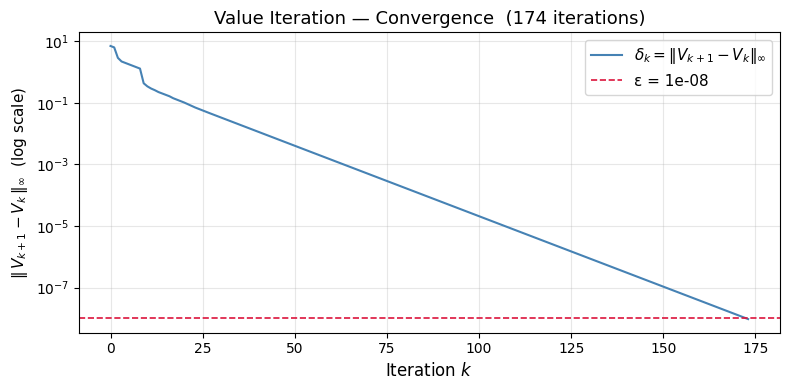

Figure 1 saved: convergence.png


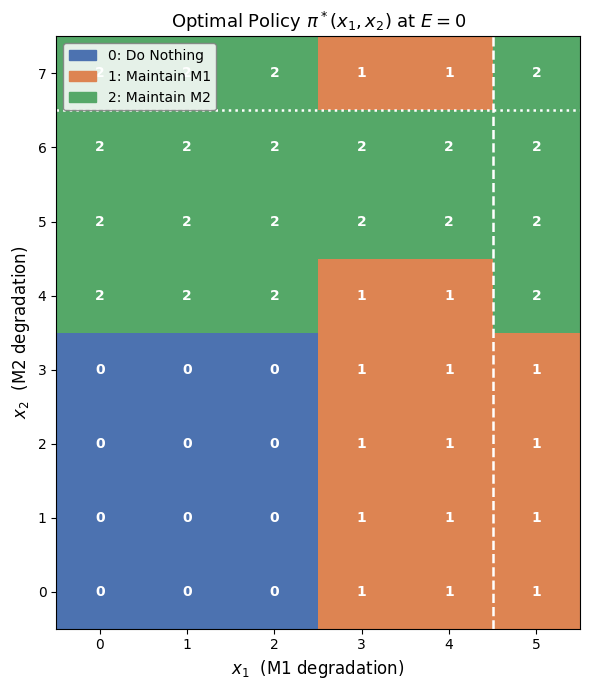

Figure 2 saved: optimal_policy.png


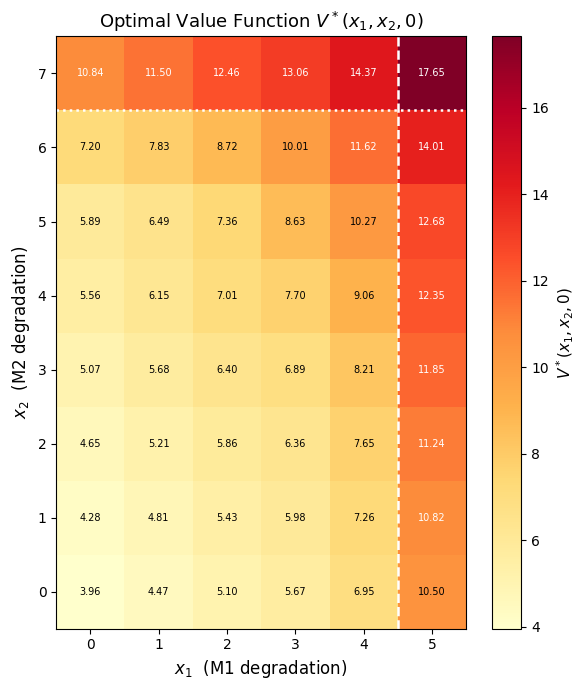

Figure 3 saved: value_function.png


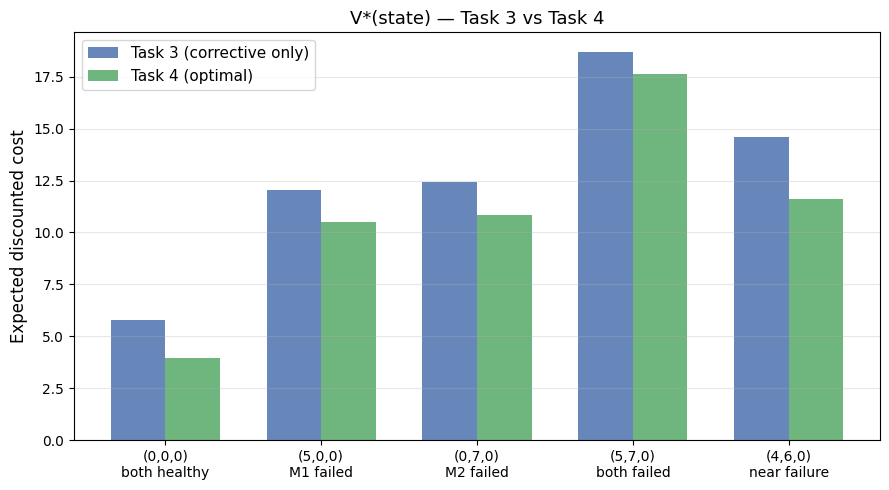

Figure 4 saved: task3_vs_task4.png

All figures saved to: /Users/cris/Desktop/RLAssignment1Task4Plots


In [8]:
#  Task 4: Visualisations
# Run this after the VI cell — needs V, pi, deltas, n_iter to be in memory
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

plot_dir = "/Users/cris/Desktop/RLAssignment1Task4Plots"
os.makedirs(plot_dir, exist_ok=True)

# Figure 1: convergence — delta_k should shrink geometrically at rate ~gamma per iteration
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(deltas, color="steelblue", linewidth=1.5, label=r"$\delta_k = \|V_{k+1}-V_k\|_\infty$")
ax.axhline(eps, color="crimson", linestyle="--", linewidth=1.2, label=f"ε = {eps:.0e}")
ax.set_xlabel("Iteration $k$", fontsize=12)
ax.set_ylabel(r"$\|\,V_{k+1} - V_k\,\|_\infty$  (log scale)", fontsize=11)
ax.set_title(f"Value Iteration — Convergence  ({n_iter} iterations)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "convergence.png"), dpi=150)
plt.show()
print("Figure 1 saved: convergence.png")

# Figure 2: optimal policy heatmap — 3 colours, one per action
cmap_pol = mcolors.ListedColormap(["#4C72B0", "#DD8452", "#55A868"])
bounds   = [-0.5, 0.5, 1.5, 2.5]
norm_pol = mcolors.BoundaryNorm(bounds, cmap_pol.N)

fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(pi.T, origin="lower", cmap=cmap_pol, norm=norm_pol,
          extent=[-0.5, n_x1 - 0.5, -0.5, n_x2 - 0.5], aspect="auto")

ax.set_xlabel("$x_1$  (M1 degradation)", fontsize=12)
ax.set_ylabel("$x_2$  (M2 degradation)", fontsize=12)
ax.set_title(r"Optimal Policy $\pi^*(x_1, x_2)$ at $E=0$", fontsize=13)
ax.set_xticks(range(n_x1)); ax.set_xticklabels(range(n_x1))
ax.set_yticks(range(n_x2)); ax.set_yticklabels(range(n_x2))

# dashed line = M1 failure threshold, dotted = M2
ax.axvline(xi1 - 0.5, color="white", linestyle="--", linewidth=1.8, label=f"$\\xi_1 = {xi1}$")
ax.axhline(xi2 - 0.5, color="white", linestyle=":",  linewidth=1.8, label=f"$\\xi_2 = {xi2}$")

patches = [mpatches.Patch(color="#4C72B0", label="0: Do Nothing"),
           mpatches.Patch(color="#DD8452", label="1: Maintain M1"),
           mpatches.Patch(color="#55A868", label="2: Maintain M2")]
ax.legend(handles=patches, loc="upper left", fontsize=10,
          framealpha=0.85, edgecolor="grey")

for x1 in range(n_x1):
    for x2 in range(n_x2):
        ax.text(x1, x2, str(pi[x1, x2]),
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white")

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "optimal_policy.png"), dpi=150)
plt.show()
print("Figure 2 saved: optimal_policy.png")

print(f"\nAll figures saved to: {plot_dir}")